## Scalogram-Based Spectral Classification Pipeline

This notebook classifies herbarium leaf spectra into plant species using:
  1. Spectral preprocessing: vector normalization → 2nd derivative (Savitzky-Golay)
  2. Continuous Wavelet Transform (CWT) with Mexican Hat wavelet → scalograms
  3. Feature engineering from scalograms
  4. Traditional ML: Random Forest, XGBoost, SVM (with stratified CV)
  5. Deep Learning: 2D CNN on scalograms (Computer Vision approach).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

In [ ]:
!pip install scikit-learn

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt

from scipy.signal import savgol_filter
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

# =============================================================================
# CONFIGURATION
# =============================================================================
# Adjust DATA_DIR for Colab environment
DATA_DIR = "/content/drive/MyDrive/floora" # Assuming data files are in /content/data/
OUTPUT_DIR = os.path.join(DATA_DIR, "results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Spectral params (matching R notebook)
WVL_START = 400
WVL_END = 2400
WVL_STEP = 5
WAVELENGTHS = np.arange(WVL_START, WVL_END + 1, WVL_STEP)  # 401 bands

# CWT params (matching R notebook)
CWT_WAVELET = "mexh"  # Mexican Hat wavelet
CWT_SCALES = np.arange(1, 11)  # scales 1..10

# Savitzky-Golay params (matching R: p=3, n=11, m=2)
SG_WINDOW = 11
SG_POLYORDER = 3
SG_DERIV = 2

# CV params
N_FOLDS = 5

# CNN params
CNN_EPOCHS = 60
CNN_BATCH_SIZE = 32
CNN_LR = 1e-3
CNN_WEIGHT_DECAY = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


### 1. Data Loading and Merging

This section loads the metadata and spectra CSVs and merges them based on filename.

In [ ]:
# =============================================================================
# 1. DATA LOADING & MERGING FUNCTIONS
# =============================================================================
def load_and_merge_data():
    """Load metadata and spectra CSVs, merge on filename."""
    print("=" * 70)
    print("STEP 1: Loading and merging data")
    print("=" * 70)

    meta_train = pd.read_csv(os.path.join(DATA_DIR, "metadata_train2.csv"))
    meta_test = pd.read_csv(os.path.join(DATA_DIR, "metadata_test2.csv"))
    spectra = pd.read_csv(os.path.join(DATA_DIR, "spectra_aggregated.csv"))

    print(f"  Training metadata:  {meta_train.shape[0]} samples")
    print(f"  Test metadata:      {meta_test.shape[0]} samples")
    print(f"  Spectra:            {spectra.shape[0]} rows x {spectra.shape[1] - 1} bands")

    # Join on filename
    train_df = meta_train.merge(spectra, on="filename", how="inner")
    test_df = meta_test.merge(spectra, on="filename", how="inner")

    print(f"  After merge — Train: {train_df.shape[0]}, Test: {test_df.shape[0]}")

    # Species distribution
    species_counts = train_df["species"].value_counts()
    print(f"\n  Species in training: {len(species_counts)}")
    print(f"  Species distribution:")
    for sp, cnt in species_counts.items():
        marker = " << RARE" if cnt < 10 else ""
        print(f"    {cnt:5d}  {sp}{marker}")

    return train_df, test_df

# Execute data loading
train_df, test_df = load_and_merge_data()

# Encode species labels
le = LabelEncoder()
y_train = le.fit_transform(train_df["species"].values)

test_species = test_df["species"].values
y_test = np.array([
    le.transform([s])[0] if s in le.classes_ else -1
    for s in test_species
])
valid_test_mask = y_test >= 0
print(f"\n  Label-encoded classes: {len(le.classes_)}")
print(f"  Test samples with known species: {valid_test_mask.sum()}/{len(y_test)}")

n_classes = len(le.classes_)


STEP 1: Loading and merging data
  Training metadata:  1201 samples
  Test metadata:      336 samples
  Spectra:            1537 rows x 2181 bands
  After merge — Train: 1201, Test: 336

  Species in training: 26
  Species distribution:
       72  Betula populifolia
       63  Spiraea alba
       63  Acer saccharum
       60  Acer spicatum
       57  Acer rubrum
       57  Osmunda spectabilis
       57  Rubus idaeus
       54  Prunus serotina
       54  Acer saccharinum
       51  Prunus pensylvanica
       48  Fagus grandifolia
       48  Solidago gigantea
       48  Ostrya virginiana
       48  Populus grandidentata
       48  Betula papyrifera
       46  Quercus rubra
       45  Phalaris arundinacea
       44  Claytosmunda claytoniana
       42  Phragmites australis
       42  Helianthus divaricatus
       39  Solidago altissima
       36  Myrica gale
       36  Rubus odoratus
       34  Populus tremuloides
        6  Quercus velutina << RARE
        3  Osmunda regalis << RARE

  La

### 2. Spectral Preprocessing Functions

This part defines functions for extracting spectral matrices, vector normalization, and calculating the second derivative using Savitzky-Golay filter.

In [ ]:
# =============================================================================
# 2. SPECTRAL PREPROCESSING FUNCTIONS
# =============================================================================
def extract_spectral_matrix(df):
    """Extract the spectral reflectance matrix for the selected wavelengths."""
    wvl_cols = [str(w) for w in WAVELENGTHS]
    available = [c for c in wvl_cols if c in df.columns]
    if len(available) < len(wvl_cols):
        print(f"  Warning: {len(wvl_cols) - len(available)} wavelength cols missing, using {len(available)}")
    return df[available].values.astype(np.float64), np.array([int(c) for c in available])


def vector_normalize(spectra_matrix):
    """L2 vector normalization (matches R spectrolab::normalize)."""
    norms = np.linalg.norm(spectra_matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return spectra_matrix / norms


def second_derivative(spectra_matrix):
    """2nd derivative via Savitzky-Golay (matches R: sgolayfilt(p=3, n=11, m=2))."""
    return savgol_filter(
        spectra_matrix,
        window_length=SG_WINDOW,
        polyorder=SG_POLYORDER,
        deriv=SG_DERIV,
        axis=1
    )


def preprocess_spectra(df, label=""):
    """Full preprocessing pipeline: extract -> normalize -> 2nd derivative."""
    print(f"\n{'=' * 70}")
    print(f"STEP 2: Preprocessing spectra ({label})")
    print(f"{'=' * 70}")

    raw, wvls = extract_spectral_matrix(df)
    print(f"  Raw spectra shape: {raw.shape}")

    normed = vector_normalize(raw)
    print(f"  After vector normalization: {normed.shape}")

    deriv2 = second_derivative(normed)
    print(f"  After 2nd derivative (SG): {deriv2.shape}")

    return deriv2, wvls

# Execute preprocessing
spectra_train, wvls = preprocess_spectra(train_df, label="train")
spectra_test, _ = preprocess_spectra(test_df, label="test")



STEP 2: Preprocessing spectra (train)
  Raw spectra shape: (1201, 401)
  After vector normalization: (1201, 401)
  After 2nd derivative (SG): (1201, 401)

STEP 2: Preprocessing spectra (test)
  Raw spectra shape: (336, 401)
  After vector normalization: (336, 401)
  After 2nd derivative (SG): (336, 401)


### 3. Scalogram Generation (CWT) and Example Plotting

This section computes Continuous Wavelet Transform (CWT) scalograms and plots examples for visualization.

In [ ]:
# =============================================================================
# 3. SCALOGRAM GENERATION (CWT) FUNCTIONS
# =============================================================================
def compute_scalograms(spectra_2d, wvls, label=""):
    """
    Compute CWT scalograms for all spectra.
    Returns: array of shape (n_samples, n_scales, n_bands)
    """
    print(f"\n{'=' * 70}")
    print(f"STEP 3: Computing CWT scalograms ({label})")
    print(f"{'=' * 70}")
    print(f"  Wavelet: {CWT_WAVELET}")
    print(f"  Scales:  {CWT_SCALES[0]}..{CWT_SCALES[-1]} ({len(CWT_SCALES)} scales)")

    n_samples = spectra_2d.shape[0]
    n_bands = spectra_2d.shape[1]
    n_scales = len(CWT_SCALES)

    scalograms = np.zeros((n_samples, n_scales, n_bands), dtype=np.float64)

    for i in range(n_samples):
        coeffs, freqs = pywt.cwt(spectra_2d[i], CWT_SCALES, CWT_WAVELET)
        scalograms[i] = coeffs

        if (i + 1) % 200 == 0 or i == 0:
            print(f"  Processed {i + 1}/{n_samples} scalograms...")

    print(f"  Scalograms shape: {scalograms.shape}")
    return scalograms


def plot_scalogram_example(scalogram, wvls, scales, title, filepath):
    """Plot an example scalogram."""
    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.imshow(
        scalogram, aspect="auto", cmap="RdBu_r",
        extent=[wvls[0], wvls[-1], scales[-1], scales[0]]
    )
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Scale")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="CWT Coefficient")
    plt.tight_layout()
    plt.savefig(filepath, dpi=150)
    plt.close() # Close plot to prevent it from displaying twice
    print(f"  Saved: {filepath}")

# Execute scalogram computation
scalograms_train = compute_scalograms(spectra_train, wvls, label="train")
scalograms_test = compute_scalograms(spectra_test, wvls, label="test")

# Plot example scalograms
print(f"\n{'=' * 70}")
print(f"Plotting example scalograms")
print(f"{'=' * 70}")
for cls_idx in range(min(3, n_classes)): # Plot for up to 3 classes
    sample_indices = np.where(y_train == cls_idx)[0]
    if len(sample_indices) > 0:
        sample_idx = sample_indices[0]
        sp_name = le.classes_[cls_idx]
        plot_scalogram_example(
            scalograms_train[sample_idx],
            wvls,
            CWT_SCALES,
            f"Scalogram -- {sp_name}",
            os.path.join(OUTPUT_DIR, f"scalogram_example_{sp_name.replace(' ', '_')}.png")
        )
    else:
        print(f"  No samples found for class {le.classes_[cls_idx]} to plot.")



STEP 3: Computing CWT scalograms (train)
  Wavelet: mexh
  Scales:  1..10 (10 scales)
  Processed 1/1201 scalograms...
  Processed 200/1201 scalograms...
  Processed 400/1201 scalograms...
  Processed 600/1201 scalograms...
  Processed 800/1201 scalograms...
  Processed 1000/1201 scalograms...
  Processed 1200/1201 scalograms...
  Scalograms shape: (1201, 10, 401)

STEP 3: Computing CWT scalograms (test)
  Wavelet: mexh
  Scales:  1..10 (10 scales)
  Processed 1/336 scalograms...
  Processed 200/336 scalograms...
  Scalograms shape: (336, 10, 401)

Plotting example scalograms
  Saved: /content/drive/MyDrive/floora/results/scalogram_example_Acer_rubrum.png
  Saved: /content/drive/MyDrive/floora/results/scalogram_example_Acer_saccharinum.png
  Saved: /content/drive/MyDrive/floora/results/scalogram_example_Acer_saccharum.png


### 4. Feature Engineering from Scalograms & 5. PCA Dimensionality Reduction

This section extracts various features from the computed scalograms for use with traditional ML models and then applies PCA for dimensionality reduction.

In [ ]:
# =============================================================================
# 4. FEATURE ENGINEERING FROM SCALOGRAMS FUNCTION
# =============================================================================
def extract_scalogram_features(scalograms, label=""):
    """
    Extract features from scalograms for traditional ML:
      1. Flattened CWT coefficients (n_scales x n_bands)
      2. Per-scale statistics: mean, std, skew, kurtosis, max, min, energy
      3. Per-band max-scale index
    """
    print(f"\n{'=' * 70}")
    print(f"STEP 4: Extracting scalogram features ({label})")
    print(f"{'=' * 70}")

    n_samples, n_scales, n_bands = scalograms.shape
    features_list = []

    # (a) Flattened scalogram coefficients
    flat = scalograms.reshape(n_samples, -1)
    print(f"  Flattened coefficients: {flat.shape[1]} features")
    features_list.append(flat)

    # (b) Per-scale statistics
    stats_features = []
    for s in range(n_scales):
        scale_data = scalograms[:, s, :]
        stats = np.column_stack([
            np.mean(scale_data, axis=1),
            np.std(scale_data, axis=1),
            skew(scale_data, axis=1),
            kurtosis(scale_data, axis=1),
            np.max(scale_data, axis=1),
            np.min(scale_data, axis=1),
            np.sum(scale_data ** 2, axis=1),  # energy
        ])
        stats_features.append(stats)
    per_scale = np.hstack(stats_features)
    print(f"  Per-scale statistics:   {per_scale.shape[1]} features")
    features_list.append(per_scale)

    # (c) Per-band max-scale index
    max_scale_idx = np.argmax(np.abs(scalograms), axis=1).astype(np.float64)
    print(f"  Per-band max-scale:     {max_scale_idx.shape[1]} features")
    features_list.append(max_scale_idx)

    all_features = np.hstack(features_list)
    print(f"  Total feature vector:   {all_features.shape[1]} features per sample")

    all_features = np.nan_to_num(all_features, nan=0.0, posinf=0.0, neginf=0.0)

    return all_features


# =============================================================================
# 5. PCA DIMENSIONALITY REDUCTION FUNCTION
# =============================================================================
def apply_pca(X_train, X_test, variance_ratio=0.99):
    """Fit PCA on training data, transform both sets."""
    print(f"\n{'=' * 70}")
    print(f"STEP 5: PCA dimensionality reduction")
    print(f"{'=' * 70}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=variance_ratio, svd_solver="full")
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    print(f"  Original dimensions:   {X_train.shape[1]}")
    print(f"  PCA components (99%):  {pca.n_components_}")
    print(f"  Explained variance:    {pca.explained_variance_ratio_.sum():.4f}")

    return X_train_pca, X_test_pca, scaler, pca

# Execute feature extraction and PCA
X_train_feat = extract_scalogram_features(scalograms_train, label="train")
X_test_feat = extract_scalogram_features(scalograms_test, label="test")

X_train_pca, X_test_pca, scaler, pca = apply_pca(X_train_feat, X_test_feat)



STEP 4: Extracting scalogram features (train)
  Flattened coefficients: 4010 features
  Per-scale statistics:   70 features
  Per-band max-scale:     401 features
  Total feature vector:   4481 features per sample

STEP 4: Extracting scalogram features (test)
  Flattened coefficients: 4010 features
  Per-scale statistics:   70 features
  Per-band max-scale:     401 features
  Total feature vector:   4481 features per sample

STEP 5: PCA dimensionality reduction
  Original dimensions:   4481
  PCA components (99%):  214
  Explained variance:    0.9900


### 6. Traditional ML Models with Cross-Validation

This section defines and trains various traditional machine learning models (Random Forest, XGBoost, SVM) using stratified K-fold cross-validation.

In [ ]:
# =============================================================================
# 6. TRADITIONAL ML MODELS WITH CROSS-VALIDATION FUNCTION
# =============================================================================
def train_traditional_models(X_train, y_train, le):
    """Train RF, XGBoost, SVM with stratified 5-fold CV."""
    print(f"\n{'=' * 70}")
    print(f"STEP 6: Traditional ML models (Stratified {N_FOLDS}-Fold CV)")
    print(f"{'=' * 70}")

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            eval_metric="mlogloss",
        ),
        "SVM_RBF": SVC(
            kernel="rbf",
            C=10.0,
            gamma="scale",
            class_weight="balanced",
            random_state=42,
            probability=True,
        ),
    }

    results = {}

    for name, model in models.items():
        print(f"\n  --- {name} ---")

        y_pred_cv = cross_val_predict(model, X_train, y_train, cv=skf, n_jobs=-1)
        cv_acc = accuracy_score(y_train, y_pred_cv)
        cv_f1 = f1_score(y_train, y_pred_cv, average="macro")

        print(f"  CV Accuracy:  {cv_acc:.4f}")
        print(f"  CV Macro-F1:  {cv_f1:.4f}")

        fold_accs = []
        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            fold_pred = y_pred_cv[val_idx]
            fold_true = y_train[val_idx]
            fold_acc = accuracy_score(fold_true, fold_pred)
            fold_accs.append(fold_acc)

        print(f"  Per-fold Acc: {[f'{a:.4f}' for a in fold_accs]}")
        print(f"  Mean +/- Std: {np.mean(fold_accs):.4f} +/- {np.std(fold_accs):.4f}")

        # Fit on full training set
        model.fit(X_train, y_train)
        results[name] = {
            "model": model,
            "cv_accuracy": cv_acc,
            "cv_f1": cv_f1,
            "y_pred_cv": y_pred_cv,
        }

    return results

# Execute traditional ML training
ml_results = train_traditional_models(X_train_pca, y_train, le)



STEP 6: Traditional ML models (Stratified 5-Fold CV)

  --- RandomForest ---
  CV Accuracy:  0.9500
  CV Macro-F1:  0.9460
  Per-fold Acc: ['0.9502', '0.9500', '0.9542', '0.9333', '0.9625']
  Mean +/- Std: 0.9500 +/- 0.0095

  --- XGBoost ---
  CV Accuracy:  0.8893
  CV Macro-F1:  0.8893
  Per-fold Acc: ['0.8963', '0.8833', '0.8833', '0.9000', '0.8833']
  Mean +/- Std: 0.8893 +/- 0.0073

  --- SVM_RBF ---
  CV Accuracy:  0.9858
  CV Macro-F1:  0.9862
  Per-fold Acc: ['1.0000', '0.9792', '0.9792', '0.9833', '0.9875']
  Mean +/- Std: 0.9858 +/- 0.0077


### 7. 2D CNN on Scalograms (Computer Vision approach)

This section defines the PyTorch Dataset and CNN model architecture, along with functions for training the CNN with cross-validation and training a final model.

In [ ]:
# =============================================================================
# 7. 2D CNN ON SCALOGRAMS (Computer Vision approach) FUNCTIONS
# =============================================================================

class ScalogramDataset(Dataset):
    """PyTorch dataset for scalogram images."""

    def __init__(self, scalograms, labels=None):
        # Treat as single-channel images: (N, H, W) -> (N, 1, H, W)
        self.data = torch.FloatTensor(scalograms).unsqueeze(1)

        # Per-sample normalization to [0, 1]
        for i in range(self.data.shape[0]):
            vmin = self.data[i].min()
            vmax = self.data[i].max()

            if vmax - vmin > 0:
                self.data[i] = (self.data[i] - vmin) / (vmax - vmin)

        self.labels = (
            torch.LongTensor(labels)
            if labels is not None
            else None
        )

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        if self.labels is not None:
            return self.data[idx], self.labels[idx]

        return self.data[idx]


class ScalogramCNN(nn.Module):
    """
    2D CNN for scalogram classification.

    Treats each scalogram (n_scales x n_bands) as a single-channel image.

    Input:
        (batch, 1, n_scales, n_bands)

    Uses asymmetric kernels because the scalogram dimensions have
    different meanings:
        - Height: wavelet scales
        - Width: wavelength/frequency bands
    """

    def __init__(self, n_classes, n_scales=10, n_bands=401):
        super().__init__()

        self.features = nn.Sequential(
            # -----------------------------------------------------------------
            # Block 1
            # Input:  (1, 10, 401)
            # Output: (32, 10, 200)
            # -----------------------------------------------------------------
            nn.Conv2d(
                1, 32,
                kernel_size=(3, 7),
                padding=(1, 3)
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(1, 2)),

            # -----------------------------------------------------------------
            # Block 2
            # Input:  (32, 10, 200)
            # Output: (64, 5, 100)
            # -----------------------------------------------------------------
            nn.Conv2d(
                32, 64,
                kernel_size=(3, 5),
                padding=(1, 2)
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),

            # -----------------------------------------------------------------
            # Block 3
            # Input:  (64, 5, 100)
            # Output: (128, 5, 50)
            # -----------------------------------------------------------------
            nn.Conv2d(
                64, 128,
                kernel_size=(3, 3),
                padding=(1, 1)
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(1, 2)),

            # -----------------------------------------------------------------
            # Block 4
            # Input:  (128, 5, 50)
            # Conv:   (256, 5, 50)
            # Pool:   (256, 2, 8)
            # -----------------------------------------------------------------
            nn.Conv2d(
                128, 256,
                kernel_size=(3, 3),
                padding=(1, 1)
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((2, 8)),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 2 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)

        # Flatten: (batch, 256, 2, 8) -> (batch, 4096)
        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x


def compute_class_weights(labels, n_classes):
    """Compute balanced class weights for loss function."""

    counts = np.bincount(
        labels,
        minlength=n_classes
    ).astype(np.float32)

    # Prevent division by zero for classes absent from a fold
    counts[counts == 0] = 1.0

    weights = len(labels) / (n_classes * counts)

    return torch.FloatTensor(weights).to(DEVICE)


def train_cnn_fold(
    model,
    train_loader,
    val_loader,
    n_classes,
    y_train_fold,
    epochs=CNN_EPOCHS
):
    """
    Train CNN for one CV fold.

    Returns:
        val_preds: Best-model predictions on validation set
        best_val_acc: Best validation accuracy
        model: Trained model restored to best checkpoint
    """

    # -------------------------------------------------------------------------
    # Class-balanced loss
    # -------------------------------------------------------------------------
    class_weights = compute_class_weights(
        y_train_fold,
        n_classes
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )

    # -------------------------------------------------------------------------
    # Optimizer
    # -------------------------------------------------------------------------
    optimizer = optim.AdamW(
        model.parameters(),
        lr=CNN_LR,
        weight_decay=CNN_WEIGHT_DECAY
    )

    # -------------------------------------------------------------------------
    # Learning-rate scheduler
    # -------------------------------------------------------------------------
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    model.to(DEVICE)

    best_val_acc = -1.0
    best_state = None

    # =========================================================================
    # Training loop
    # =========================================================================
    for epoch in range(epochs):

        # ---------------------------------------------------------------------
        # Training
        # ---------------------------------------------------------------------
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for data, target in train_loader:
            data = data.to(DEVICE)
            target = target.to(DEVICE)

            optimizer.zero_grad()

            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * data.size(0)

            pred = output.argmax(dim=1)

            train_correct += pred.eq(target).sum().item()
            train_total += data.size(0)

        scheduler.step()

        train_loss = (
            train_loss / train_total
            if train_total > 0
            else 0.0
        )

        train_acc = (
            train_correct / train_total
            if train_total > 0
            else 0.0
        )

        # ---------------------------------------------------------------------
        # Validation
        # ---------------------------------------------------------------------
        model.eval()

        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in val_loader:
                data = data.to(DEVICE)
                target = target.to(DEVICE)

                output = model(data)
                pred = output.argmax(dim=1)

                val_correct += pred.eq(target).sum().item()
                val_total += data.size(0)

        val_acc = (
            val_correct / val_total
            if val_total > 0
            else 0.0
        )

        # ---------------------------------------------------------------------
        # Save best model
        # ---------------------------------------------------------------------
        if val_acc > best_val_acc:
            best_val_acc = val_acc

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        # ---------------------------------------------------------------------
        # Logging
        # ---------------------------------------------------------------------
        if (epoch + 1) % 20 == 0:
            print(
                f"    Epoch {epoch + 1}/{epochs} -- "
                f"Train Loss: {train_loss:.4f}, "
                f"Train Acc: {train_acc:.4f}, "
                f"Val Acc: {val_acc:.4f}"
            )

    # =========================================================================
    # Restore best model
    # =========================================================================
    if best_state is not None:
        model.load_state_dict(best_state)

    model.to(DEVICE)
    model.eval()

    # =========================================================================
    # Get validation predictions using best model
    # =========================================================================
    val_preds = []

    with torch.no_grad():
        for data, _ in val_loader:
            data = data.to(DEVICE)

            output = model(data)

            pred = output.argmax(dim=1).cpu().numpy()

            # FIX: append to val_preds, not undefined `preds`
            val_preds.extend(pred)

    return np.array(val_preds), best_val_acc, model


def train_cnn_with_cv(scalograms_train, y_train, n_classes):
    """Train 2D CNN with stratified K-fold CV."""

    print(f"\n{'=' * 70}")
    print(f"STEP 7: 2D CNN on Scalograms (CV approach)")
    print(f"{'=' * 70}")

    print(f"  Device:      {DEVICE}")
    print(
        f"  Input shape: "
        f"(1, {scalograms_train.shape[1]}, {scalograms_train.shape[2]})"
    )
    print(f"  Classes:     {n_classes}")
    print(f"  Epochs:      {CNN_EPOCHS}")

    # Full dataset
    dataset = ScalogramDataset(
        scalograms_train,
        y_train
    )

    # Stratified K-fold CV
    skf = StratifiedKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=42
    )

    # Store out-of-fold predictions
    all_val_preds = np.zeros(
        len(y_train),
        dtype=np.int64
    )

    fold_accs = []

    for fold_idx, (train_idx, val_idx) in enumerate(
        skf.split(scalograms_train, y_train)
    ):

        print(
            f"\n  --- Fold {fold_idx + 1}/{N_FOLDS} ---"
        )

        # ---------------------------------------------------------------------
        # Training loader
        # ---------------------------------------------------------------------
        train_sampler = SubsetRandomSampler(train_idx)

        train_loader = DataLoader(
            dataset,
            batch_size=CNN_BATCH_SIZE,
            sampler=train_sampler
        )

        # ---------------------------------------------------------------------
        # Validation loader
        # ---------------------------------------------------------------------
        val_dataset = ScalogramDataset(
            scalograms_train[val_idx],
            y_train[val_idx]
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=CNN_BATCH_SIZE,
            shuffle=False
        )

        # ---------------------------------------------------------------------
        # New model for each fold
        # ---------------------------------------------------------------------
        model = ScalogramCNN(
            n_classes,
            n_scales=scalograms_train.shape[1],
            n_bands=scalograms_train.shape[2]
        )

        y_train_fold = y_train[train_idx]

        # ---------------------------------------------------------------------
        # Train
        # ---------------------------------------------------------------------
        val_preds, val_acc, trained_model = train_cnn_fold(
            model,
            train_loader,
            val_loader,
            n_classes,
            y_train_fold
        )

        # Store predictions in their original sample positions
        all_val_preds[val_idx] = val_preds

        fold_accs.append(val_acc)

        print(
            f"  Fold {fold_idx + 1} Best Val Acc: "
            f"{val_acc:.4f}"
        )

    # =========================================================================
    # Overall CV metrics
    # =========================================================================
    cv_acc = accuracy_score(
        y_train,
        all_val_preds
    )

    cv_f1 = f1_score(
        y_train,
        all_val_preds,
        average="macro"
    )

    print("\n  CNN CV Results:")
    print(f"  CV Accuracy:  {cv_acc:.4f}")
    print(f"  CV Macro-F1:  {cv_f1:.4f}")
    print(
        f"  Per-fold Acc: "
        f"{[f'{a:.4f}' for a in fold_accs]}"
    )
    print(
        f"  Mean +/- Std: "
        f"{np.mean(fold_accs):.4f} +/- {np.std(fold_accs):.4f}"
    )

    return {
        "cv_accuracy": cv_acc,
        "cv_f1": cv_f1,
        "y_pred_cv": all_val_preds,
    }


def train_final_cnn(
    scalograms_train,
    y_train,
    n_classes,
    epochs=None
):
    """Train final CNN on the full training set."""

    if epochs is None:
        epochs = CNN_EPOCHS + 20

    print(
        f"\n  Training final CNN on full training set "
        f"({epochs} epochs)..."
    )

    # -------------------------------------------------------------------------
    # Dataset and loader
    # -------------------------------------------------------------------------
    dataset = ScalogramDataset(
        scalograms_train,
        y_train
    )

    loader = DataLoader(
        dataset,
        batch_size=CNN_BATCH_SIZE,
        shuffle=True
    )

    # -------------------------------------------------------------------------
    # Model
    # -------------------------------------------------------------------------
    model = ScalogramCNN(
        n_classes,
        n_scales=scalograms_train.shape[1],
        n_bands=scalograms_train.shape[2]
    )

    model.to(DEVICE)

    # -------------------------------------------------------------------------
    # Loss
    # -------------------------------------------------------------------------
    class_weights = compute_class_weights(
        y_train,
        n_classes
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )

    # -------------------------------------------------------------------------
    # Optimizer + scheduler
    # -------------------------------------------------------------------------
    optimizer = optim.AdamW(
        model.parameters(),
        lr=CNN_LR,
        weight_decay=CNN_WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    # =========================================================================
    # Training
    # =========================================================================
    model.train()

    for epoch in range(epochs):

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for data, target in loader:

            data = data.to(DEVICE)
            target = target.to(DEVICE)

            optimizer.zero_grad()

            output = model(data)

            loss = criterion(
                output,
                target
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * data.size(0)

            total_correct += (
                output.argmax(dim=1)
                .eq(target)
                .sum()
                .item()
            )

            total_samples += data.size(0)

        scheduler.step()

        if (epoch + 1) % 20 == 0:

            print(
                f"    Epoch {epoch + 1}/{epochs} -- "
                f"Loss: {total_loss / total_samples:.4f}, "
                f"Acc: {total_correct / total_samples:.4f}"
            )

    return model


def predict_cnn(model, scalograms):
    """Predict classes with a trained CNN."""

    # Labels are dummy values because prediction does not require labels
    dataset = ScalogramDataset(
        scalograms,
        labels=np.zeros(
            len(scalograms),
            dtype=int
        )
    )

    loader = DataLoader(
        dataset,
        batch_size=CNN_BATCH_SIZE,
        shuffle=False
    )

    model.to(DEVICE)
    model.eval()

    preds = []

    with torch.no_grad():

        for data, _ in loader:

            data = data.to(DEVICE)

            output = model(data)

            pred = (
                output
                .argmax(dim=1)
                .cpu()
                .numpy()
            )

            preds.extend(pred)

    return np.array(preds)


# =============================================================================
# Execute CNN training
# =============================================================================

cnn_cv_results = train_cnn_with_cv(
    scalograms_train,
    y_train,
    n_classes
)


STEP 7: 2D CNN on Scalograms (CV approach)
  Device:      cuda
  Input shape: (1, 10, 401)
  Classes:     26
  Epochs:      60

  --- Fold 1/5 ---
    Epoch 20/60 -- Train Loss: 1.1952, Train Acc: 0.5396, Val Acc: 0.4398
    Epoch 40/60 -- Train Loss: 0.5550, Train Acc: 0.7677, Val Acc: 0.7386
    Epoch 60/60 -- Train Loss: 0.4315, Train Acc: 0.8510, Val Acc: 0.8506
  Fold 1 Best Val Acc: 0.8589

  --- Fold 2/5 ---
    Epoch 20/60 -- Train Loss: 1.5085, Train Acc: 0.4495, Val Acc: 0.5000
    Epoch 40/60 -- Train Loss: 0.9965, Train Acc: 0.5858, Val Acc: 0.6625
    Epoch 60/60 -- Train Loss: 0.7338, Train Acc: 0.7190, Val Acc: 0.7833
  Fold 2 Best Val Acc: 0.7833

  --- Fold 3/5 ---
    Epoch 20/60 -- Train Loss: 1.4274, Train Acc: 0.4714, Val Acc: 0.5042
    Epoch 40/60 -- Train Loss: 0.7615, Train Acc: 0.6951, Val Acc: 0.6583
    Epoch 60/60 -- Train Loss: 0.6718, Train Acc: 0.7305, Val Acc: 0.7792
  Fold 3 Best Val Acc: 0.7792

  --- Fold 4/5 ---
    Epoch 20/60 -- Train Loss: 1.544

### 8. Evaluation & Visualization Functions

This section provides functions for evaluating model predictions on the test set, generating classification reports, and plotting confusion matrices.

In [ ]:
# =============================================================================
# 8. EVALUATION & VISUALIZATION FUNCTIONS
# =============================================================================
def plot_confusion_matrix(y_true, y_pred, class_names, title, filepath, normalize=False):
    """Plot and save confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = ".2f"
        title = f"{title} (Normalized)"
    else:
        fmt = "d"

    fig, ax = plt.subplots(figsize=(16, 14))

    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.5, linecolor="gray"
    )
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150)
    plt.close()
    print(f"  Saved: {filepath}")


def evaluate_on_test(model_name, y_pred, y_test, le):
    """Evaluate predictions on the test set."""
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average="macro")

    print(f"\n  {model_name} -- Test Set Results:")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  Macro-F1: {test_f1:.4f}")

    # Classification report
    report = classification_report(
        y_test, y_pred,
        labels=range(len(le.classes_)),
        target_names=le.classes_,
        zero_division=0
    )
    print(f"\n{report}")

    # Save report
    report_path = os.path.join(OUTPUT_DIR, f"report_{model_name}.txt")
    with open(report_path, "w") as f:
        f.write(f"{model_name} -- Test Set Classification Report\n")
        f.write(f"{'=' * 60}\n")
        f.write(f"Accuracy: {test_acc:.4f}\n")
        f.write(f"Macro-F1: {test_f1:.4f}\n\n")
        f.write(report)
    print(f"  Saved: {report_path}")

    # Confusion matrix
    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_{model_name}.png")
    plot_confusion_matrix(
        y_test, y_pred, le.classes_,
        f"{model_name} -- Confusion Matrix (Test)", cm_path
    )

    return test_acc, test_f1

### 9. Final Evaluation on Test Set and Summary

This section evaluates all trained models on the test set, summarizes their performance, and saves predictions and comparison metrics.

In [ ]:
# =============================================================================
# 9. FINAL EVALUATION AND SUMMARY
# =============================================================================
print(f"\n{'=' * 70}")
print(f"STEP 8: Final evaluation on test set")
print(f"{'=' * 70}")

X_test_eval = X_test_pca[valid_test_mask]
y_test_eval = y_test[valid_test_mask]
scalograms_test_eval = scalograms_test[valid_test_mask]

test_results = {}

# Traditional ML models
for name, result in ml_results.items():
    y_pred = result["model"].predict(X_test_eval)
    acc, f1 = evaluate_on_test(name, y_pred, y_test_eval, le)
    test_results[name] = {"accuracy": acc, "f1": f1, "predictions": y_pred}

# CNN
final_cnn = train_final_cnn(scalograms_train, y_train, n_classes)
cnn_preds = predict_cnn(final_cnn, scalograms_test_eval)
cnn_acc, cnn_f1 = evaluate_on_test("CNN_2D", cnn_preds, y_test_eval, le)
test_results["CNN_2D"] = {"accuracy": cnn_acc, "f1": cnn_f1, "predictions": cnn_preds}

# ------------------------------------------------------------------
# Summary & save predictions
# ------------------------------------------------------------------
print(f"\n{'=' * 70}")
print(f"SUMMARY: Model Comparison")
print(f"{'=' * 70}")
print(f"{'Model':<20} {'CV Acc':>10} {'CV F1':>10} {'Test Acc':>10} {'Test F1':>10}")
print("-" * 60)

all_model_names = list(ml_results.keys()) + ["CNN_2D"]
for name in all_model_names:
    if name in ml_results:
        cv_acc = ml_results[name]["cv_accuracy"]
        cv_f1 = ml_results[name]["cv_f1"]
    else:
        cv_acc = cnn_cv_results["cv_accuracy"]
        cv_f1 = cnn_cv_results["cv_f1"]

    test_acc = test_results[name]["accuracy"]
    test_f1 = test_results[name]["f1"]

    print(f"{name:<20} {cv_acc:>10.4f} {cv_f1:>10.4f} {test_acc:>10.4f} {test_f1:>10.4f}")

# Find best model
best_name = max(test_results, key=lambda k: test_results[k]["f1"])
print(f"\n  Best model by Test F1: {best_name} "
      f"(Acc={test_results[best_name]['accuracy']:.4f}, "
      f"F1={test_results[best_name]['f1']:.4f})")

# Save predictions
pred_df = test_df[valid_test_mask][["filename", "species"]].copy()
pred_df = pred_df.reset_index(drop=True)
pred_df["true_species"] = test_species[valid_test_mask]
for name in all_model_names:
    pred_df[f"pred_{name}"] = le.inverse_transform(test_results[name]["predictions"])

pred_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
pred_df.to_csv(pred_path, index=False)
print(f"\n  Saved predictions: {pred_path}")

# Save model comparison
summary_path = os.path.join(OUTPUT_DIR, "model_comparison.csv")
summary_rows = []
for name in all_model_names:
    row = {"model": name}
    if name in ml_results:
        row["cv_accuracy"] = ml_results[name]["cv_accuracy"]
        row["cv_f1"] = ml_results[name]["cv_f1"]
    else:
        row["cv_accuracy"] = cnn_cv_results["cv_accuracy"]
        row["cv_f1"] = cnn_cv_results["cv_f1"]
    row["test_accuracy"] = test_results[name]["accuracy"]
    row["test_f1"] = test_results[name]["f1"]
    summary_rows.append(row)

pd.DataFrame(summary_rows).to_csv(summary_path, index=False)
print(f"  Saved comparison: {summary_path}")

print(f"\n{'=' * 70}")
print(f"  PIPELINE COMPLETE!")
print(f"{'=' * 70}\n")



STEP 8: Final evaluation on test set

  RandomForest -- Test Set Results:
  Accuracy: 0.6847
  Macro-F1: 0.6643

                          precision    recall  f1-score   support

             Acer rubrum       0.67      0.53      0.59        15
        Acer saccharinum       0.67      0.53      0.59        15
          Acer saccharum       0.57      0.80      0.67        15
           Acer spicatum       0.45      0.75      0.56        12
       Betula papyrifera       1.00      0.80      0.89        15
      Betula populifolia       0.69      0.95      0.80        21
Claytosmunda claytoniana       0.71      0.83      0.77        12
       Fagus grandifolia       0.80      0.80      0.80        15
  Helianthus divaricatus       0.80      1.00      0.89        12
             Myrica gale       0.70      0.78      0.74         9
         Osmunda regalis       0.00      0.00      0.00         0
     Osmunda spectabilis       0.45      0.75      0.56        12
       Ostrya virginiana   

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pywt
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import LabelEncoder
import shap
from sklearn.metrics import classification_report # Added for direct classification report

# Settings
DATA_DIR = "/content/drive/MyDrive/floora" # Assuming data files are in /content/data/
OUTPUT_DIR = os.path.join(DATA_DIR, "results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

CWT_WAVELET = "mexh"
CWT_SCALES = np.arange(1, 11)
CNN_EPOCHS = 15
CNN_BATCH_SIZE = 32

def load_data():
    spectra = pd.read_csv(os.path.join(DATA_DIR, "spectra_aggregated.csv"))
    meta_train = pd.read_csv(os.path.join(DATA_DIR, "metadata_train.csv"))
    meta_test = pd.read_csv(os.path.join(DATA_DIR, "metadata_test.csv"))

    # Preprocess spectra columns
    spectra.columns = spectra.columns.str.replace("X", "")
    wvl_cols = [c for c in spectra.columns if c.isdigit()]
    wvls = np.array([float(w) for w in wvl_cols])

    train_df = meta_train.merge(spectra, on="filename", how="inner")
    test_df = meta_test.merge(spectra, on="filename", how="inner")

    # Extract hierarchical labels
    taxa_cols = ["class", "order", "family", "genus", "species"]
    encoders = {col: LabelEncoder() for col in taxa_cols}

    for col in taxa_cols:
        combined = pd.concat([train_df[col], test_df[col]])
        encoders[col].fit(combined)
        train_df[f"{col}_id"] = encoders[col].transform(train_df[col])
        test_df[f"{col}_id"] = encoders[col].transform(test_df[col])

    X_train = train_df[wvl_cols].fillna(0).values
    y_train_taxa = train_df[[f"{c}_id" for c in taxa_cols]].values

    X_test = test_df[wvl_cols].fillna(0).values
    y_test_taxa = test_df[[f"{c}_id" for c in taxa_cols]].values

    return X_train, y_train_taxa, X_test, y_test_taxa, wvls, encoders

def compute_scalograms(spectra_2d, wvls):
    print("Computing scalograms...")
    scalograms = []
    for i in range(len(spectra_2d)):
        coeffs, _ = pywt.cwt(spectra_2d[i], CWT_SCALES, CWT_WAVELET)
        scalograms.append(coeffs)
    return np.array(scalograms)

class ScalogramTaxaDataset(Dataset):
    def __init__(self, scalograms, taxa_labels):
        self.X = torch.tensor(scalograms, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(taxa_labels, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class SpecTaxaEmbedder(nn.Module):
    def __init__(self, n_scales, n_bands, embed_dim=128, num_classes=0): # Added num_classes
        super().__init__()
        self.embed_dim = embed_dim
        self.num_classes = num_classes

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(3, 7), padding=(1, 3)),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2, 4)),

            nn.Conv2d(16, 32, kernel_size=(3, 7), padding=(1, 3)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 4)),
        )
        self.flatten = nn.Flatten()

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_scales, n_bands)
            out = self.features(dummy)
            hidden_dim = out.numel()

        self.projection = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Linear(256, self.embed_dim)
        )

        # Optional classification head
        if self.num_classes > 0:
            self.classifier = nn.Linear(self.embed_dim, self.num_classes)
        else:
            self.classifier = None

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        embeddings = F.normalize(self.projection(x), p=2, dim=1)

        if self.classifier is not None:
            logits = self.classifier(embeddings)
            return embeddings, logits # Return both
        else:
            return embeddings # Only return embeddings if no classifier

class HierarchicalContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.1, weight_species=1.0, weight_genus=1.0, weight_family=1.0):
        super().__init__()
        self.temperature = temperature
        self.weight_species = weight_species
        self.weight_genus = weight_genus
        self.weight_family = weight_family

    def forward(self, embeddings, taxa_labels):
        device = embeddings.device
        batch_size = embeddings.size(0)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature

        weights = torch.zeros((batch_size, batch_size), device=device)

        # Get match matrices for each level
        # taxa_labels structure: [class, order, family, genus, species]
        species_match = (taxa_labels[:, 4].unsqueeze(1) == taxa_labels[:, 4].T).float()
        genus_match = (taxa_labels[:, 3].unsqueeze(1) == taxa_labels[:, 3].T).float()
        family_match = (taxa_labels[:, 2].unsqueeze(1) == taxa_labels[:, 2].T).float()

        # Assign weights based on hierarchical matches
        # Strongest weight for species match
        weights += species_match * self.weight_species

        # Weaker weight for genus match ONLY if species are different
        # (1 - species_match) ensures that if species match, this term is 0
        weights += genus_match * (1 - species_match) * self.weight_genus

        # Even weaker weight for family match ONLY if genus (and thus species) are different
        # (1 - genus_match) ensures that if genus match, this term is 0
        weights += family_match * (1 - genus_match) * self.weight_family

        # Ensure no self-similarity is considered for loss calculation
        mask = torch.eye(batch_size, device=device).bool()
        weights.masked_fill_(mask, 0)

        # Apply mask to similarity matrix to ignore self-similarity
        sim_matrix.masked_fill_(mask, -1e9) # Set diagonal to a very small number for softmax stability

        log_prob = F.log_softmax(sim_matrix, dim=1)

        # Calculate loss
        # Avoid division by zero if a row has no positive pairs (sum of weights is 0)
        sum_weights_per_row = weights.sum(dim=1)
        # Only calculate loss for rows where there are positive pairs, otherwise loss is 0 for that row
        # This handles cases where a sample might not have any matching labels at any level other than itself
        valid_rows_mask = (sum_weights_per_row > 1e-8) # Use a small epsilon to avoid floating point issues

        # Compute loss for valid rows
        loss_per_row = - (weights * log_prob).sum(dim=1) / (sum_weights_per_row + 1e-8)

        # Return the mean of the loss for valid rows, or 0 if no valid rows
        if valid_rows_mask.any():
            return loss_per_row[valid_rows_mask].mean()
        else:
            return torch.tensor(0.0, device=device) # Return 0 loss if no positive pairs found in batch

def train_embedder(model, loader, epochs=CNN_EPOCHS, lr=1e-3): # Added num_classes
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    contrastive_criterion = HierarchicalContrastiveLoss() # Use default weights
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    has_classifier = (model.classifier is not None)
    if has_classifier:
        classification_criterion = nn.CrossEntropyLoss() # For species prediction
        print("Training SpecTaxa-Embed (with direct species classification head)...")
    else:
        print("Training SpecTaxa-Embed (contrastive only)...")

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        total_correct_clf = 0 # For classification accuracy
        total_samples_clf = 0 # For classification accuracy

        for x, y_taxa in loader:
            x, y_taxa = x.to(device), y_taxa.to(device)
            optimizer.zero_grad()

            if has_classifier:
                embeddings, logits = model(x)
                contrastive_loss = contrastive_criterion(embeddings, y_taxa)
                species_labels = y_taxa[:, 4] # Species is the 5th column (index 4)
                classification_loss = classification_criterion(logits, species_labels)
                loss = contrastive_loss + classification_loss # Combine losses
                # Track classification accuracy
                preds = logits.argmax(dim=1)
                total_correct_clf += preds.eq(species_labels).sum().item()
                total_samples_clf += x.size(0)
            else:
                embeddings = model(x)
                loss = contrastive_criterion(embeddings, y_taxa)

            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)

        epoch_loss = total_loss / len(loader.dataset)
        log_str = f"  Epoch {epoch+1}/{epochs} | Total Loss: {epoch_loss:.4f}"
        if has_classifier:
            epoch_accuracy = total_correct_clf / total_samples_clf if total_samples_clf > 0 else 0.0
            log_str += f", Species Acc: {epoch_accuracy:.4f}"
        print(log_str)
    return model

def plot_umap(embeddings, labels, label_names, title, filepath):
    print(f"Generating UMAP for {title}...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    embedding_2d = reducer.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    unique_labels = np.unique(labels)
    for l in unique_labels:
        idx = (labels == l)
        plt.scatter(embedding_2d[idx, 0], embedding_2d[idx, 1], label=label_names[l], alpha=0.7, s=20)

    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150)
    plt.close()

def extract_shap(model_for_shap, x_sample, x_background): # Renamed model to model_for_shap
    print("Extracting SHAP values...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_for_shap.eval()

    explainer = shap.GradientExplainer(model_for_shap, x_background.to(device))
    shap_values = explainer.shap_values(x_sample.to(device))

    # If SHAP returns a list of length `num_classes`, where each element is (batch, c, h, w)
    if isinstance(shap_values, list):
        shap_values = np.array(shap_values) # Shape: (num_classes, batch, c, h, w)
        # Average over output classes (axis 0) to get overall importance per input
        return np.mean(np.abs(shap_values), axis=0)

    shap_values = np.array(shap_values)

    # If SHAP returns a single array of shape (batch, num_classes, c, h, w)
    if shap_values.ndim == 5:
        # Average over output classes (axis 1) to get overall importance per input
        return np.mean(np.abs(shap_values), axis=1)

    # If it's already shape (batch, c, h, w) (e.g., if model only had 1 output class)
    return np.abs(shap_values)

def main():
    X_train, y_train_taxa, X_test, y_test_taxa, wvls, encoders = load_data()

    sc_train = compute_scalograms(X_train, wvls)
    sc_test = compute_scalograms(X_test, wvls)

    train_dataset = ScalogramTaxaDataset(sc_train, y_train_taxa)
    test_dataset = ScalogramTaxaDataset(sc_test, y_test_taxa)

    train_loader = DataLoader(train_dataset, batch_size=CNN_BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=CNN_BATCH_SIZE, shuffle=False)

    n_scales = sc_train.shape[1]
    n_bands = sc_train.shape[2]
    n_species = len(encoders["species"].classes_) # Get number of species for classification

    # Initialize model with classification head
    model = SpecTaxaEmbedder(n_scales, n_bands, num_classes=n_species)
    model = train_embedder(model, train_loader)

    device = next(model.parameters()).device
    model.eval() # Set to evaluation mode
    all_embeddings = []
    all_species_preds = [] # To store direct species predictions
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            # The model now returns (embeddings, logits) if num_classes > 0
            embeddings, logits = model(x)
            all_embeddings.append(embeddings.cpu().numpy())
            all_species_preds.append(logits.argmax(dim=1).cpu().numpy()) # Store predictions

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_species_preds = np.concatenate(all_species_preds, axis=0)

    # UMAP plots (still use embeddings)
    family_labels = y_test_taxa[:, 2]
    family_names = encoders["family"].classes_
    plot_umap(all_embeddings, family_labels, family_names, "UMAP: Test Set by Family", "umap_family_rec.png")

    genus_labels = y_test_taxa[:, 3]
    genus_names = encoders["genus"].classes_
    plot_umap(all_embeddings, genus_labels, genus_names, "UMAP: Test Set by Genus", "umap_genus_rec.png")

    species_labels = y_test_taxa[:, 4]
    species_names = encoders["species"].classes_
    plot_umap(all_embeddings, species_labels, species_names, "UMAP: Test Set by Species", "umap_species_rec.png")

    # Evaluate direct species classification from SpecTaxaEmbedder
    print("\n" + "=" * 70)
    print("Direct Species Classification Report from SpecTaxaEmbedder (combined loss)")
    print("=" * 70)
    report = classification_report(
        species_labels, all_species_preds,
        labels=range(len(species_names)),
        target_names=species_names,
        zero_division=0
    )
    print(report)
    print("=" * 70)

    # SHAP explanation for the direct species prediction
    # Create a wrapper model that only returns the logits for SHAP
    class ClassificationWrapper(nn.Module):
        def __init__(self, embedder_model):
            super().__init__()
            self.embedder_model = embedder_model

        def forward(self, x):
            _, logits = self.embedder_model(x)
            return logits

    # Instantiate the wrapper with the trained model
    shap_model_wrapper = ClassificationWrapper(model)

    bg_samples = train_dataset.X[:50]
    test_samples = test_dataset.X[:5]

    # Use the wrapper model for SHAP explanation
    shap_maps = extract_shap(shap_model_wrapper, test_samples, bg_samples)

    for i in range(5):
        sp_name = encoders["species"].classes_[y_test_taxa[i, 4]]
        fig, ax = plt.subplots(figsize=(10, 4))
        im = ax.imshow(
            shap_maps[i, 0], aspect="auto", cmap="hot",
            extent=[wvls[0], wvls[-1], CWT_SCALES[-1], CWT_SCALES[0]]
        )
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Wavelet Scale")
        ax.set_title(f"SHAP Importance Map for Species Prediction: {sp_name}")
        plt.colorbar(im, ax=ax, label="Mean |SHAP Value|")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, f"shap_map_species_prediction_sample_{i}.png"), dpi=150)
        plt.close()

    print("SpecTaxa-Embed complete! Results saved to:", OUTPUT_DIR)
    return all_species_preds, y_test_taxa, encoders

all_species_preds, y_test_taxa, encoders = main()


Computing scalograms...
Computing scalograms...
Training SpecTaxa-Embed (with direct species classification head)...
  Epoch 1/15 | Total Loss: 6.6092, Species Acc: 0.0659
  Epoch 2/15 | Total Loss: 6.0255, Species Acc: 0.1058
  Epoch 3/15 | Total Loss: 5.5779, Species Acc: 0.1725
  Epoch 4/15 | Total Loss: 5.2625, Species Acc: 0.2327
  Epoch 5/15 | Total Loss: 5.0280, Species Acc: 0.2620
  Epoch 6/15 | Total Loss: 4.7720, Species Acc: 0.2962
  Epoch 7/15 | Total Loss: 4.4827, Species Acc: 0.3214
  Epoch 8/15 | Total Loss: 4.2846, Species Acc: 0.3629
  Epoch 9/15 | Total Loss: 4.0902, Species Acc: 0.3775
  Epoch 10/15 | Total Loss: 3.9527, Species Acc: 0.3922
  Epoch 11/15 | Total Loss: 3.7390, Species Acc: 0.4020
  Epoch 12/15 | Total Loss: 3.6669, Species Acc: 0.4255
  Epoch 13/15 | Total Loss: 3.5589, Species Acc: 0.4255
  Epoch 14/15 | Total Loss: 3.5356, Species Acc: 0.4353
  Epoch 15/15 | Total Loss: 3.3891, Species Acc: 0.4557
Generating UMAP for UMAP: Test Set by Family...
Gene

In [ ]:
# Assuming all_embeddings and y_test_taxa are available from the previous execution of main() in -FlJ72pDYavl.
# If not, the main() function from -FlJ72pDYavl would need to be re-executed or modified to return these.

# Re-load encoders to ensure they are consistent, if main() was not just run
X_train, y_train_taxa, X_test, y_test_taxa, wvls, encoders = load_data()

from sklearn.neighbors import KNeighborsClassifier

taxonomic_levels_test = {
    "genus": {"idx": 3, "encoder": encoders["genus"]},
    "family": {"idx": 2, "encoder": encoders["family"]}
}

print('\n' + '=' * 70)
print('K-NN Classification Reports on Test Set (SpecTaxaEmbedder Embeddings)')
print('=' * 70)

# Need to generate train embeddings to fit KNN
sc_train = compute_scalograms(X_train, wvls)
train_dataset = ScalogramTaxaDataset(sc_train, y_train_taxa)
train_loader = DataLoader(train_dataset, batch_size=CNN_BATCH_SIZE, shuffle=False)

n_scales = sc_train.shape[1]
n_bands = sc_train.shape[2]
n_species = len(encoders["species"].classes_)

# Re-initialize and train the model to get embeddings
# This assumes the model is not globally available from previous run of main() in -FlJ72pDYavl
model = SpecTaxaEmbedder(n_scales, n_bands, num_classes=n_species) # Initialize with classification head as trained before
model = train_embedder(model, train_loader, epochs=CNN_EPOCHS, lr=CNN_LR) # Retrain the model on training data

device = next(model.parameters()).device
model.eval()

all_train_embeddings = []
with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        embeddings, _ = model(x) # Get embeddings only
        all_train_embeddings.append(embeddings.cpu().numpy())
all_train_embeddings = np.concatenate(all_train_embeddings, axis=0)

# Generate test embeddings using the retrained model
sc_test = compute_scalograms(X_test, wvls)
test_dataset = ScalogramTaxaDataset(sc_test, y_test_taxa)
test_loader = DataLoader(test_dataset, batch_size=CNN_BATCH_SIZE, shuffle=False)

all_test_embeddings = []
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        embeddings, _ = model(x)
        all_test_embeddings.append(embeddings.cpu().numpy())
all_test_embeddings = np.concatenate(all_test_embeddings, axis=0)

for level_name, level_info in taxonomic_levels_test.items():
    level_idx = level_info["idx"]
    level_encoder = level_info["encoder"]

    y_train_level = y_train_taxa[:, level_idx]
    y_test_level = y_test_taxa[:, level_idx]

    # Train a KNN classifier on the embeddings
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(all_train_embeddings, y_train_level)
    y_pred_level = knn.predict(all_test_embeddings)

    print(f"\n--- {level_name.capitalize()} Level ---")
    report_level = classification_report(
        y_test_level, y_pred_level,
        labels=range(len(level_encoder.classes_)),
        target_names=level_encoder.classes_,
        zero_division=0
    )
    print(report_level)

print('=' * 70)


K-NN Classification Reports on Test Set (SpecTaxaEmbedder Embeddings)
Computing scalograms...
Training SpecTaxa-Embed (with direct species classification head)...
  Epoch 1/15 | Total Loss: 6.8256, Species Acc: 0.0212
  Epoch 2/15 | Total Loss: 6.7196, Species Acc: 0.0472
  Epoch 3/15 | Total Loss: 6.6915, Species Acc: 0.0472
  Epoch 4/15 | Total Loss: 6.6720, Species Acc: 0.0472
  Epoch 5/15 | Total Loss: 6.6611, Species Acc: 0.0228
  Epoch 6/15 | Total Loss: 6.6481, Species Acc: 0.0358
  Epoch 7/15 | Total Loss: 6.6256, Species Acc: 0.0000
  Epoch 8/15 | Total Loss: 6.6052, Species Acc: 0.0000
  Epoch 9/15 | Total Loss: 6.5852, Species Acc: 0.0041
  Epoch 10/15 | Total Loss: 6.5611, Species Acc: 0.0041
  Epoch 11/15 | Total Loss: 6.5458, Species Acc: 0.0244
  Epoch 12/15 | Total Loss: 6.5357, Species Acc: 0.0529
  Epoch 13/15 | Total Loss: 6.5556, Species Acc: 0.0366
  Epoch 14/15 | Total Loss: 6.5042, Species Acc: 0.0732
  Epoch 15/15 | Total Loss: 6.4693, Species Acc: 0.0814
Compu

In [ ]:
from sklearn.metrics import classification_report, f1_score

# Ensure `all_species_preds` and `y_test_taxa` (species labels) are available.
# If this cell is run independently, you might need to re-execute the `main()` function or ensure these variables are globally accessible.

species_labels_test = y_test_taxa[:, 4] # Species is the 5th column (index 4)
species_names_test = encoders["species"].classes_

# Calculate the classification report
report_direct_species = classification_report(
    species_labels_test, all_species_preds,
    labels=range(len(species_names_test)),
    target_names=species_names_test,
    zero_division=0
)

# Extract macro average F1 score
macro_f1_direct_species = f1_score(species_labels_test, all_species_preds, average='macro', zero_division=0)

print('\n' + '=' * 70)
print('Direct Species Classification F1 Score (Test Set)')
print('=' * 70)
print(f"Macro Avg F1 Score: {macro_f1_direct_species:.4f}")
print('\nFull Classification Report:\n')
print(report_direct_species)
print('=' * 70)


Direct Species Classification F1 Score (Test Set)
Macro Avg F1 Score: 0.3510

Full Classification Report:

                          precision    recall  f1-score   support

             Acer rubrum       0.29      0.71      0.42        14
        Acer saccharinum       0.29      0.14      0.19        14
          Acer saccharum       0.33      0.19      0.24        16
           Acer spicatum       0.18      0.29      0.22        14
       Betula papyrifera       0.67      0.31      0.42        13
      Betula populifolia       0.45      0.89      0.60        19
Claytosmunda claytoniana       0.00      0.00      0.00        11
       Fagus grandifolia       0.67      0.77      0.71        13
  Helianthus divaricatus       0.00      0.00      0.00        11
    Morella pensylvanica       0.00      0.00      0.00         0
             Myrica gale       0.86      0.60      0.71        10
         Osmunda regalis       0.00      0.00      0.00         0
     Osmunda spectabilis       0.

### Confusion Matrix for SpecTaxaEmbedder Direct Species Classification (Test Set)

  Saved: /content/drive/MyDrive/floora/results/confusion_matrix_SpecTaxaEmbedder_direct_species_normalized.png


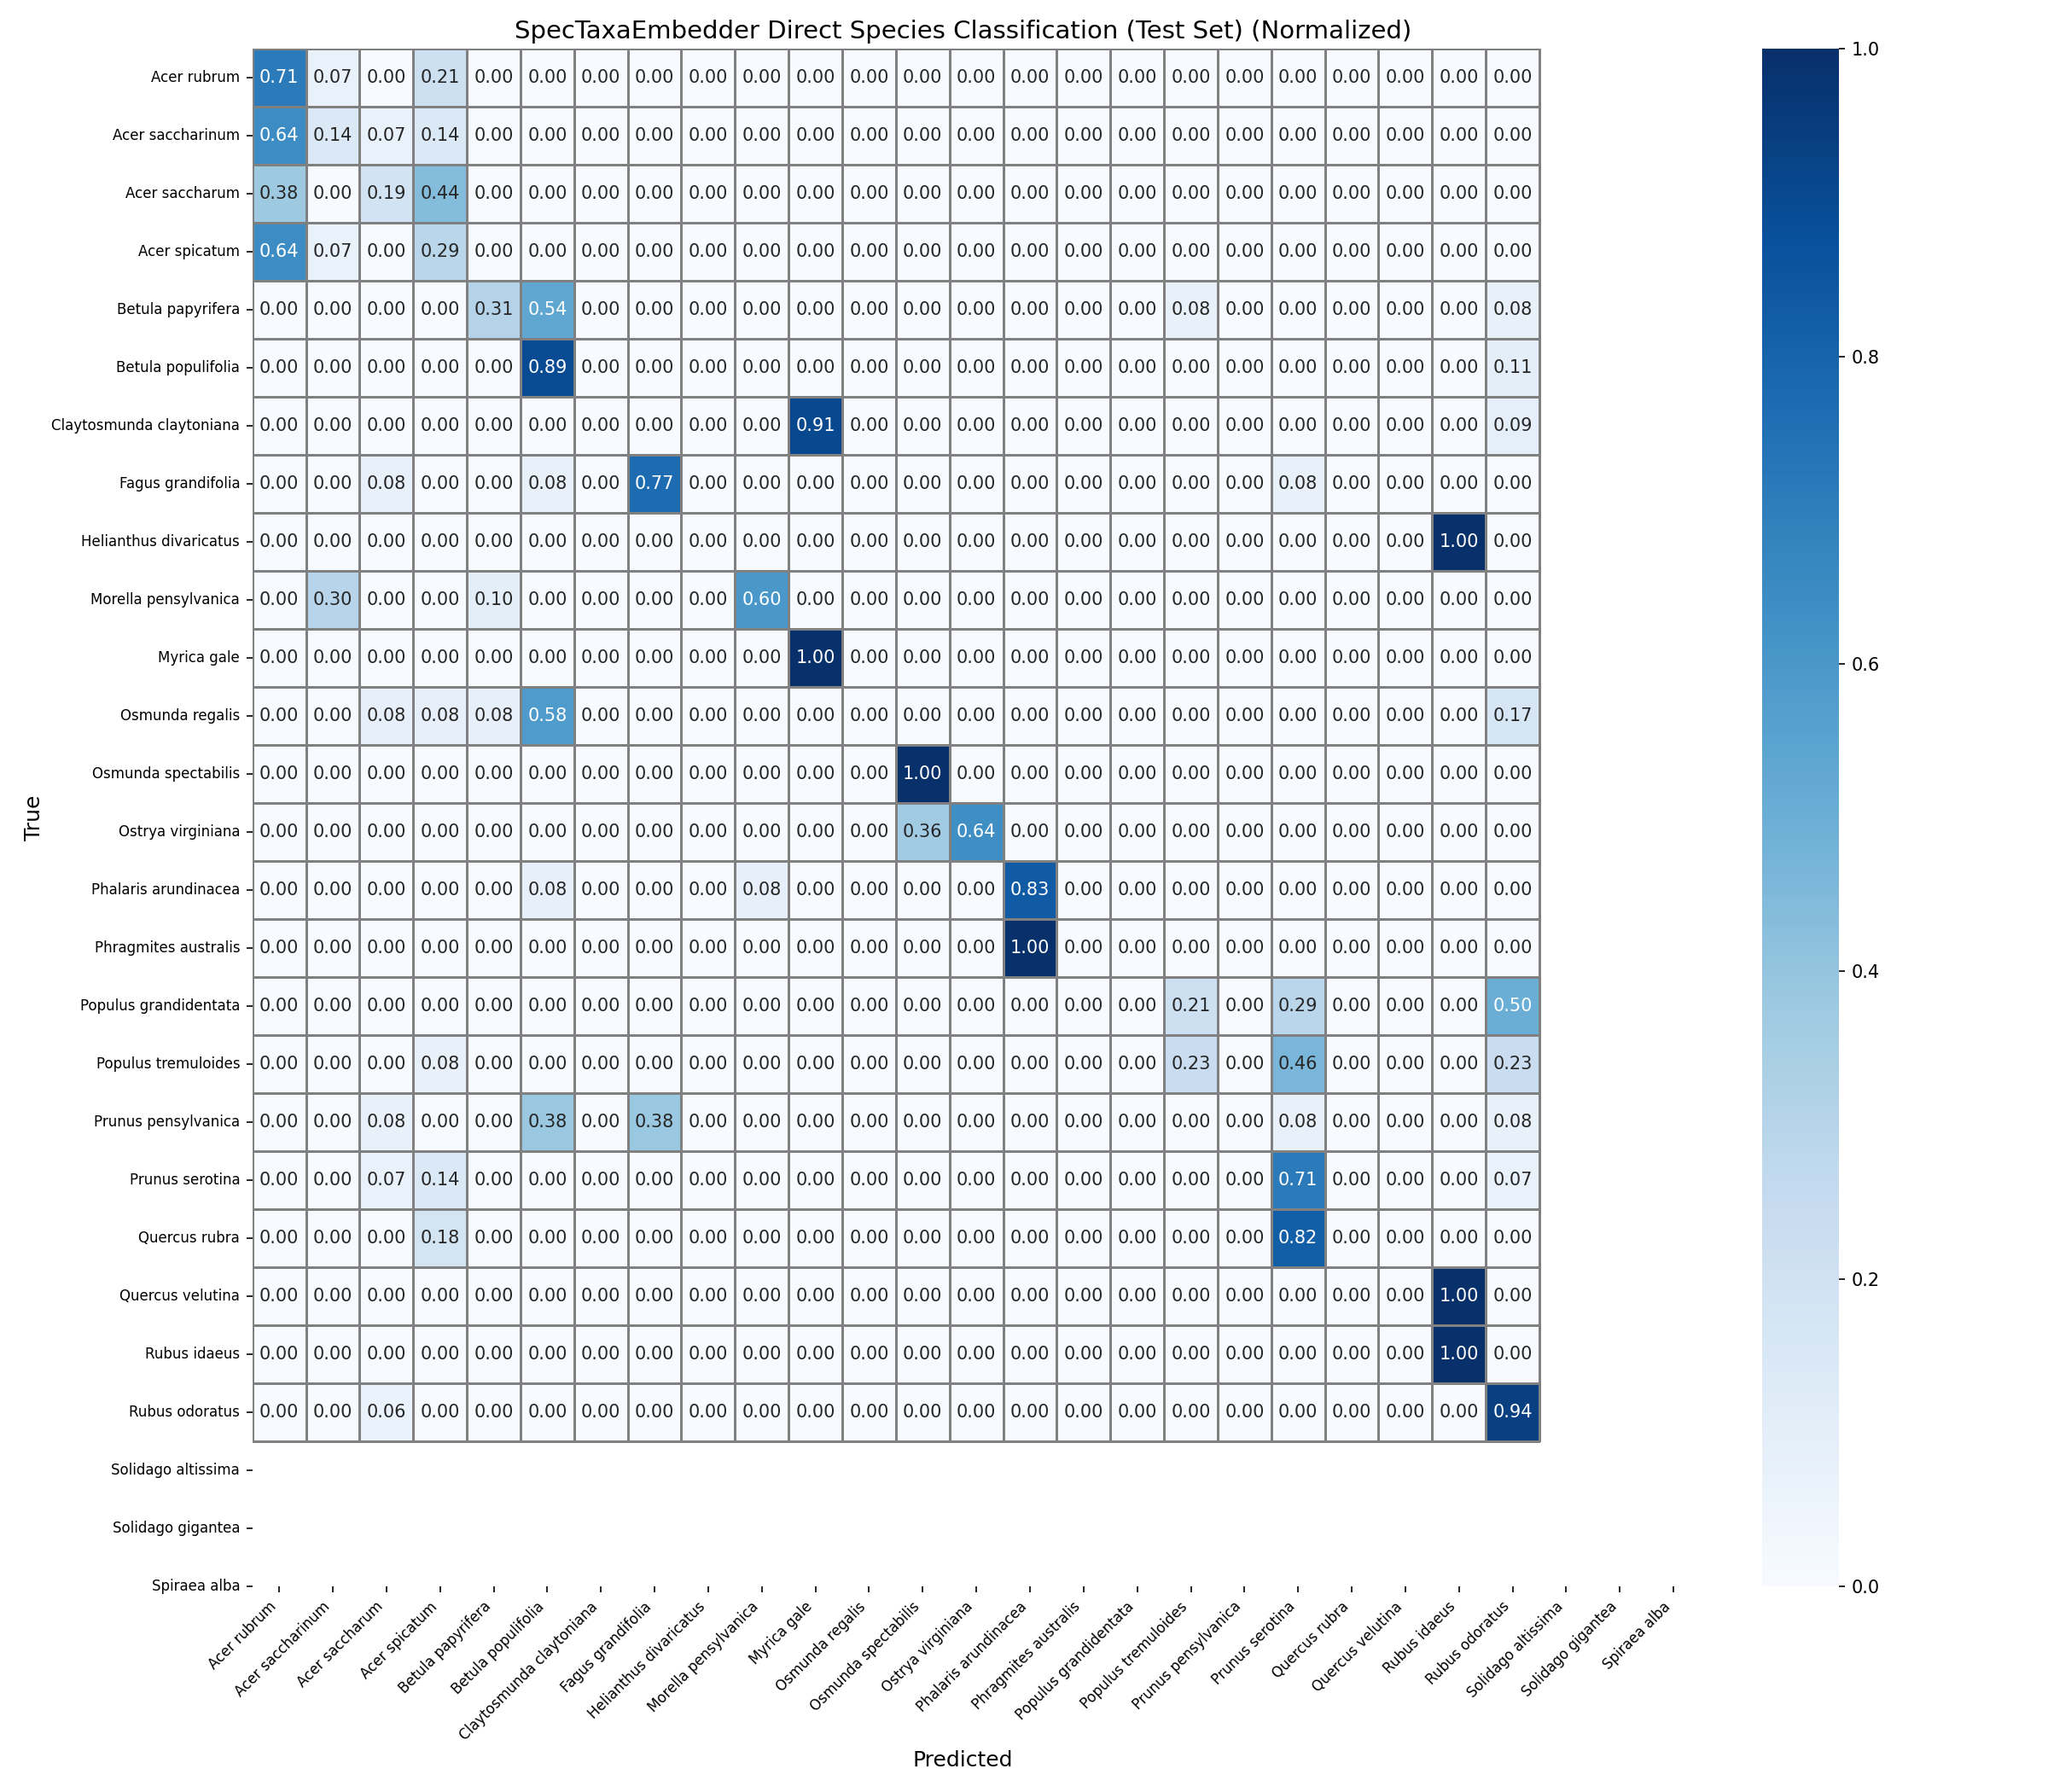

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

species_labels_test = y_test_taxa[:, 4] # Species is the 5th column (index 4)
species_names_test = encoders["species"].classes_

# Generate and plot confusion matrix
plt_cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix_SpecTaxaEmbedder_direct_species_normalized.png") # Changed filename for normalized version
plot_confusion_matrix(
    species_labels_test,
    all_species_preds,
    species_names_test,
    "SpecTaxaEmbedder Direct Species Classification (Test Set)",
    plt_cm_path,
    normalize=True # Added normalize=True
)

display(Image(filename=plt_cm_path))

### Embedding Space for 2D CNN (Direct Classifier)

In [ ]:
import umap
import matplotlib.pyplot as plt

# Helper function to extract features (embeddings) from the ScalogramCNN model
class ScalogramCNNExtractor(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.features = original_model.features
        # ScalogramCNN flattens its features using x.view(x.size(0), -1) directly
        # so we don't need to copy a 'flatten' attribute. We'll do it in forward.

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Manually flatten, consistent with ScalogramCNN's forward
        return x

# Instantiate the extractor using the final_cnn model from cell `f657ab64`
# Note: `final_cnn` is assumed to be available from previous execution. If not, re-run cell `f657ab64`.
cnn_extractor = ScalogramCNNExtractor(final_cnn)
cnn_extractor.eval().to(DEVICE)

# Prepare test data for feature extraction
scalograms_test_tensor = torch.FloatTensor(scalograms_test_eval).unsqueeze(1).to(DEVICE)

# Extract embeddings
with torch.no_grad():
    cnn_embeddings = cnn_extractor(scalograms_test_tensor).cpu().numpy()

print(f"Extracted CNN embeddings shape: {cnn_embeddings.shape}")

# Perform UMAP dimensionality reduction
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
umap_embeddings_cnn = reducer.fit_transform(cnn_embeddings)

print(f"UMAP reduced embeddings shape: {umap_embeddings_cnn.shape}")

# --- Plot UMAP embeddings colored by taxonomic levels ---

# The original `y_test_taxa` in the environment has 308 samples, which is inconsistent
# with `valid_test_mask` (336 samples) and `umap_embeddings_cnn` (333 samples).
# We need to re-derive y_test_taxa from the `test_df` (which has 336 samples, consistent
# with how `valid_test_mask` was created) and then filter by `valid_test_mask`.

taxa_cols = ["class", "order", "family", "genus", "species"]
y_test_taxa_full = np.zeros((test_df.shape[0], len(taxa_cols)), dtype=int)

for i, col in enumerate(taxa_cols):
    current_encoder = encoders[col]
    encoded_labels = []
    for val in test_df[col].values:
        if val in current_encoder.classes_:
            encoded_labels.append(current_encoder.transform([val])[0])
        else:
            # If a value is not in the encoder's classes, treat it as unknown/invalid (-1)
            # This aligns with how valid_test_mask was created for species labels.
            encoded_labels.append(-1)
    y_test_taxa_full[:, i] = np.array(encoded_labels)

# Now, we use this y_test_taxa_full which has 336 samples, and apply valid_test_mask (also 336)
# This will result in 333 samples for labels, consistent with umap_embeddings_cnn

# Species Plot
species_labels_test = y_test_taxa_full[valid_test_mask, 4] # Species is the 5th column (index 4)
species_names_test = encoders["species"].classes_
plt.figure(figsize=(10, 8))
unique_species = np.unique(species_labels_test)
for l in unique_species:
    idx = (species_labels_test == l)
    plt.scatter(umap_embeddings_cnn[idx, 0], umap_embeddings_cnn[idx, 1], label=species_names_test[l], alpha=0.7, s=20)
plt.title('UMAP: 2D CNN Embeddings by Species (Test Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "umap_cnn_species.png"), dpi=150)
plt.close()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'umap_cnn_species.png')}")

# Genus Plot
genus_labels_test = y_test_taxa_full[valid_test_mask, 3] # Genus is the 4th column (index 3)
genus_names_test = encoders["genus"].classes_
plt.figure(figsize=(10, 8))
unique_genus = np.unique(genus_labels_test)
for l in unique_genus:
    idx = (genus_labels_test == l)
    plt.scatter(umap_embeddings_cnn[idx, 0], umap_embeddings_cnn[idx, 1], label=genus_names_test[l], alpha=0.7, s=20)
plt.title('UMAP: 2D CNN Embeddings by Genus (Test Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "umap_cnn_genus.png"), dpi=150)
plt.close()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'umap_cnn_genus.png')}")

# Family Plot
family_labels_test = y_test_taxa_full[valid_test_mask, 2] # Family is the 3rd column (index 2)
family_names_test = encoders["family"].classes_
plt.figure(figsize=(10, 8))
unique_family = np.unique(family_labels_test)
for l in unique_family:
    idx = (family_labels_test == l)
    plt.scatter(umap_embeddings_cnn[idx, 0], umap_embeddings_cnn[idx, 1], label=family_names_test[l], alpha=0.7, s=20)
plt.title('UMAP: 2D CNN Embeddings by Family (Test Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "umap_cnn_family.png"), dpi=150)
plt.close()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'umap_cnn_family.png')}")

Extracted CNN embeddings shape: (333, 4096)
UMAP reduced embeddings shape: (333, 2)
Saved: /content/drive/MyDrive/floora/results/umap_cnn_species.png
Saved: /content/drive/MyDrive/floora/results/umap_cnn_genus.png
Saved: /content/drive/MyDrive/floora/results/umap_cnn_family.png


### Re-evaluating SpecTaxaEmbedder Embeddings with Random Forest Classifier for Genus and Family

In [ ]:
print('\n' + '=' * 70)
print('Deriving Genus and Family F1 from Direct Species Classification')
print('=' * 70)

# Ensure encoders and y_test_taxa are available
X_train_dummy, y_train_taxa_dummy, X_test_dummy, y_test_taxa, wvls_dummy, encoders = load_data()

# Get true labels for genus and family from y_test_taxa
true_genus_labels = y_test_taxa[:, 3]
true_family_labels = y_test_taxa[:, 2]

# Map predicted species IDs to predicted species names
predicted_species_names = encoders['species'].inverse_transform(all_species_preds)

# Create a DataFrame to help map species to genus and family
# We need the original metadata to get the mapping
meta_test = pd.read_csv(os.path.join(DATA_DIR, "metadata_test.csv"))

# Ensure unique species-to-genus/family mappings
species_to_taxa_map = meta_test.drop_duplicates(subset=['species'])[['species', 'genus', 'family']]

# Convert species to string for merging (if not already)
species_to_taxa_map['species'] = species_to_taxa_map['species'].astype(str)
predicted_species_df = pd.DataFrame({'species': predicted_species_names.astype(str)})

# Merge to get predicted genus and family names
predicted_taxa_df = pd.merge(
    predicted_species_df,
    species_to_taxa_map,
    on='species',
    how='left'
)

# Encode predicted genus and family names back to IDs using the same encoders
predicted_genus_labels = encoders['genus'].transform(predicted_taxa_df['genus'].fillna('UNKNOWN'))
predicted_family_labels = encoders['family'].transform(predicted_taxa_df['family'].fillna('UNKNOWN'))

# Calculate F1 scores for Genus
genus_f1 = f1_score(true_genus_labels, predicted_genus_labels, average='macro', zero_division=0)
print(f"Macro Avg F1 Score for Genus (from direct species prediction): {genus_f1:.4f}")

# Calculate F1 scores for Family
family_f1 = f1_score(true_family_labels, predicted_family_labels, average='macro', zero_division=0)
print(f"Macro Avg F1 Score for Family (from direct species prediction): {family_f1:.4f}")

print('=' * 70)


Deriving Genus and Family F1 from Direct Species Classification
Macro Avg F1 Score for Genus (from direct species prediction): 0.5507
Macro Avg F1 Score for Family (from direct species prediction): 0.8839


### Evaluate Contrastive Loss on Test Set

To calculate the contrastive loss on the test set, we first need to re-initialize and retrain the `SpecTaxaEmbedder` model, as the model object from the previous execution of the `main()` function was not stored globally. Then, we can use the `HierarchicalContrastiveLoss` criterion to compute the loss on the test data.

In [ ]:
print('\n' + '=' * 70)
print('Re-initializing and retraining SpecTaxaEmbedder for test loss evaluation')
print('=' * 70)

# Reload data if needed (ensures consistent state with main() from -FlJ72pDYavl)
X_train, y_train_taxa, X_test, y_test_taxa, wvls, encoders = load_data()

# Compute scalograms for training and test sets
sc_train = compute_scalograms(X_train, wvls)
sc_test = compute_scalograms(X_test, wvls)

# Create datasets and data loaders
train_dataset = ScalogramTaxaDataset(sc_train, y_train_taxa)
test_dataset = ScalogramTaxaDataset(sc_test, y_test_taxa)

train_loader = DataLoader(train_dataset, batch_size=CNN_BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CNN_BATCH_SIZE, shuffle=False)

n_scales = sc_train.shape[1]
n_bands = sc_train.shape[2]
n_species = len(encoders["species"].classes_) # Get number of species for classification

# Re-initialize and train the model with classification head (as in -FlJ72pDYavl)
model_for_loss_eval = SpecTaxaEmbedder(n_scales, n_bands, num_classes=n_species)
model_for_loss_eval = train_embedder(model_for_loss_eval, train_loader, epochs=CNN_EPOCHS, lr=CNN_LR)

print('\n' + '=' * 70)
print('SpecTaxaEmbedder retraining complete for loss evaluation')
print('=' * 70)


Re-initializing and retraining SpecTaxaEmbedder for test loss evaluation
Computing scalograms...
Computing scalograms...
Training SpecTaxa-Embed (with direct species classification head)...
  Epoch 1/15 | Total Loss: 6.4012, Species Acc: 0.0651
  Epoch 2/15 | Total Loss: 5.7131, Species Acc: 0.1774
  Epoch 3/15 | Total Loss: 5.3838, Species Acc: 0.2506
  Epoch 4/15 | Total Loss: 5.0396, Species Acc: 0.2945
  Epoch 5/15 | Total Loss: 4.8408, Species Acc: 0.2823
  Epoch 6/15 | Total Loss: 4.5594, Species Acc: 0.3303
  Epoch 7/15 | Total Loss: 4.2519, Species Acc: 0.3588
  Epoch 8/15 | Total Loss: 4.1258, Species Acc: 0.3889
  Epoch 9/15 | Total Loss: 4.0300, Species Acc: 0.3800
  Epoch 10/15 | Total Loss: 3.8260, Species Acc: 0.4003
  Epoch 11/15 | Total Loss: 3.7223, Species Acc: 0.4215
  Epoch 12/15 | Total Loss: 3.6177, Species Acc: 0.4190
  Epoch 13/15 | Total Loss: 3.4984, Species Acc: 0.4378
  Epoch 14/15 | Total Loss: 3.4010, Species Acc: 0.4646
  Epoch 15/15 | Total Loss: 3.2366

In [ ]:
def evaluate_contrastive_loss(model, data_loader, criterion):
    model.eval() # Set model to evaluation mode
    total_loss = 0.0
    device = next(model.parameters()).device

    with torch.no_grad():
        for x, y_taxa in data_loader:
            x, y_taxa = x.to(device), y_taxa.to(device)

            # Get embeddings from the model
            # If model has a classifier, it returns (embeddings, logits)
            # If not, it returns just embeddings
            model_output = model(x)
            if isinstance(model_output, tuple):
                embeddings = model_output[0]
            else:
                embeddings = model_output

            loss = criterion(embeddings, y_taxa)
            total_loss += loss.item() * x.size(0)

    avg_loss = total_loss / len(data_loader.dataset)
    return avg_loss

# Instantiate the HierarchicalContrastiveLoss criterion
# Ensure the weights match what was used for training if different from default
contrastive_criterion = HierarchicalContrastiveLoss(weight_species=1.0, weight_genus=1.0, weight_family=1.0) # Using weights from -FlJ72pDYavl

# Evaluate contrastive loss on the test set
test_contrastive_loss = evaluate_contrastive_loss(model_for_loss_eval, test_loader, contrastive_criterion)

print(f"\nTest Set Hierarchical Contrastive Loss: {test_contrastive_loss:.4f}")


Test Set Hierarchical Contrastive Loss: 2.7812


try out knn on embeddings

In [ ]:
print('\n' + '=' * 70)
print('Evaluating SpecTaxaEmbedder on Training Set')
print('=' * 70)

# Reload data if main() was already called and variables are not global
X_train, y_train_taxa, X_test, y_test_taxa, wvls, encoders = load_data()
sc_train = compute_scalograms(X_train, wvls)

train_dataset = ScalogramTaxaDataset(sc_train, y_train_taxa)
train_loader = DataLoader(train_dataset, batch_size=CNN_BATCH_SIZE, shuffle=True) # Shuffle for training

n_scales = sc_train.shape[1]
n_bands = sc_train.shape[2]
n_species = len(encoders["species"].classes_)

# Re-initialize and train the model as it was not globally available
model = SpecTaxaEmbedder(n_scales, n_bands, num_classes=n_species)
model = train_embedder(model, train_loader, epochs=CNN_EPOCHS, lr=CNN_LR) # Retrain the model

device = next(model.parameters()).device
model.eval() # Set to evaluation mode

all_train_embeddings = []
all_train_species_preds = [] # For direct classification head

with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        embeddings, logits = model(x)
        all_train_embeddings.append(embeddings.cpu().numpy())
        all_train_species_preds.append(logits.argmax(dim=1).cpu().numpy())

all_train_embeddings = np.concatenate(all_train_embeddings, axis=0);
all_train_species_preds = np.concatenate(all_train_species_preds, axis=0)

# 1. Direct Species Classification (from the combined loss head)
print('\n' + '=' * 70)
print('Direct Species Classification Report on Training Set (SpecTaxaEmbedder)')
print('=' * 70)

species_names_train = encoders["species"].classes_
species_labels_train = y_train_taxa[:, 4]

report_species_train = classification_report(
    species_labels_train, all_train_species_preds,
    labels=range(len(species_names_train)),
    target_names=species_names_train,
    zero_division=0
)
print(report_species_train)
print('=' * 70)

# 2. K-NN Classification on Embeddings for Genus and Family
from sklearn.neighbors import KNeighborsClassifier

taxonomic_levels_train = {
    "genus": {"idx": 3, "encoder": encoders["genus"]},
    "family": {"idx": 2, "encoder": encoders["family"]}
}

print('\n' + '=' * 70)
print('K-NN Classification Reports on Training Set (SpecTaxaEmbedder Embeddings)')
print('=' * 70)

for level_name, level_info in taxonomic_levels_train.items():
    level_idx = level_info["idx"]
    level_encoder = level_info["encoder"]

    y_train_level = y_train_taxa[:, level_idx]

    # Train a KNN classifier on the embeddings (this is training the KNN on training data)
    knn_train = KNeighborsClassifier(n_neighbors=5)
    knn_train.fit(all_train_embeddings, y_train_level)

    # Predict on the same training embeddings to get training F1
    y_pred_level_train = knn_train.predict(all_train_embeddings)

    print(f"\n--- {level_name.capitalize()} Level ---")
    report_level_train = classification_report(
        y_train_level, y_pred_level_train,
        labels=range(len(level_encoder.classes_)),
        target_names=level_encoder.classes_,
        zero_division=0
    )
    print(report_level_train)

print('=' * 70)


Evaluating SpecTaxaEmbedder on Training Set
Computing scalograms...
Training SpecTaxa-Embed (with direct species classification head)...
  Epoch 1/15 | Total Loss: 6.1927, Species Acc: 0.1001
  Epoch 2/15 | Total Loss: 5.5703, Species Acc: 0.1692
  Epoch 3/15 | Total Loss: 5.1756, Species Acc: 0.2783
  Epoch 4/15 | Total Loss: 4.9236, Species Acc: 0.3393
  Epoch 5/15 | Total Loss: 4.7310, Species Acc: 0.3523
  Epoch 6/15 | Total Loss: 4.3894, Species Acc: 0.3849
  Epoch 7/15 | Total Loss: 4.3506, Species Acc: 0.3930
  Epoch 8/15 | Total Loss: 4.0692, Species Acc: 0.4288
  Epoch 9/15 | Total Loss: 3.9469, Species Acc: 0.4491
  Epoch 10/15 | Total Loss: 3.7352, Species Acc: 0.4866
  Epoch 11/15 | Total Loss: 3.6593, Species Acc: 0.4988
  Epoch 12/15 | Total Loss: 3.4994, Species Acc: 0.5216
  Epoch 13/15 | Total Loss: 3.2839, Species Acc: 0.5606
  Epoch 14/15 | Total Loss: 3.2114, Species Acc: 0.5598
  Epoch 15/15 | Total Loss: 3.1310, Species Acc: 0.6078

Direct Species Classification 